# Importing Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_Fact=pd.read_excel('../Processed versions of data/Cleaned_Customer_Churn_Dataset.xlsx',sheet_name='Fact_Customer_Churn')
df_customer=pd.read_excel('../Processed versions of data/Cleaned_Customer_Churn_Dataset.xlsx',sheet_name='Dim_Customer')
df_Subscription=pd.read_excel('../Processed versions of data/Cleaned_Customer_Churn_Dataset.xlsx',sheet_name='Dim_Subscription')
df_Contract=pd.read_excel('../Processed versions of data/Cleaned_Customer_Churn_Dataset.xlsx',sheet_name='Dim_Contract')

In [3]:
df = (
    df_Fact
    .merge(df_customer, on="CustomerID", how="left")
    .merge(df_Subscription, on="Subscription Type ID", how="left")
    .merge(df_Contract, on="Contract Length ID", how="left")
)

In [4]:
df.sample(5)

,CustomerID,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Subscription Type ID,Contract Length ID,Age,Gender,Subscription Type,Contract Length
340485,347601,6,17,1,3,637.09,4,0,1,3,23,Male,Standard,Annual
64957,66397,37,21,8,14,416.00,4,1,1,3,48,Female,Standard,Annual
14232,14241,1,22,9,7,810.00,8,1,2,1,41,Female,Basic,Monthly
367543,374659,14,21,1,1,554.62,24,0,2,2,43,Male,Basic,Quarterly
88905,91387,1,15,10,4,844.00,30,1,3,1,26,Male,Premium,Monthly


# Additional useful columns for analysis

Dividing Age into groups

In [5]:
bins = [18, 30, 42, 54, 66]
labels = ["18-30", "30-42", "42-54", "54-66"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)

Dividing Tenure into groups

In [6]:
bins = [0, 12, 24, 36, 48, 60]

labels = [
    "1-Year",
    "2-Years",
    "3-Years",
    "4-Years",
    "5-Years"
]

df["Tenure_Group"] = pd.cut(df["Tenure"], bins=bins, labels=labels, right=False)

Dividing last interaction into groups

In [7]:
bins = [0, 7, 14, 30]
labels = ['Very Active [Week]', 'Active [2Weeks]', 'At Risk [More]']

df['Interaction_Level'] = pd.cut(df['Last Interaction'], bins=bins, labels=labels, right=True, include_lowest=True)

Naming Churn Values

In [8]:
df['Churn Category'] = df['Churn'].map({0: 'Retained', 1: 'Churned'})

Dividing Usage Frequency into groups

In [9]:
bins = [0, 10, 20, float("inf")]
labels = ['1–10 per month', '10–20 per month', '20+ per month']

df["Usage Group"] = pd.cut(df["Usage Frequency"], bins=bins, labels=labels, include_lowest=True)

Dividing Payment delays into groups

In [10]:
bins = [0, 10, 20, float("inf")]
labels = ['1–10 days', '10–20 days', '20+days']
df["Payment Delay Group"] = pd.cut(df["Payment Delay"], bins=bins, labels=labels, include_lowest=True)

Dividing Total Spend into groups

In [11]:

bins = np.arange(100, 1100, 100)   

labels = [f"{bins[i]} - {bins[i+1]}" for i in range(len(bins)-1)]

df['Total Spend Group'] = pd.cut(
    df['Total Spend'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False   
)


# Questions

### 💘Churn Analysis:

1. What is the overall churn rate?

In [12]:
Churn_Rate = round((len(df[df['Churn']==1]) / len(df))*100,2)
print(f'Churn Rate = {Churn_Rate}%')

Churn Rate = 56.71%


2. What are the key differences in average demographic and behavioral metrics between customers who have churned and those who are active?

In [13]:
result = df.groupby('Churn Category').agg(
    Total_Customers=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Tenure=('Tenure', 'mean'),
    Avg_Usage=('Usage Frequency', 'mean'),
    Avg_Support_Calls=('Support Calls', 'mean'),
    Avg_Payment_Delay=('Payment Delay', 'mean'),
    Avg_Total_Spend=('Total Spend', 'mean'),
    Avg_Last_Interaction=('Last Interaction', 'mean')
)

print(result)


                Total_Customers    Avg_Age  Avg_Tenure  Avg_Usage  \
Churn Category                                                      
Churned                  249999  41.747263   30.473598  15.461658   
Retained                 190833  36.262973   32.281754  16.260552   

                Avg_Support_Calls  Avg_Payment_Delay  Avg_Total_Spend  \
Churn Category                                                          
Churned                  5.144861          15.217729       541.285528   
Retained                 1.586418          10.015500       749.953111   

                Avg_Last_Interaction  
Churn Category                        
Churned                    15.604546  
Retained                   13.008804  


### 👥Demographic Analysis

3. Is there a noticeable difference in churn between males and females?

In [14]:
(df.groupby('Gender')['Churn Category'].value_counts(normalize=True)* 100).round(1).astype(str) + '%'

Gender  Churn Category
Female  Churned           66.7%
        Retained          33.3%
Male    Retained          50.9%
        Churned           49.1%
Name: proportion, dtype: object

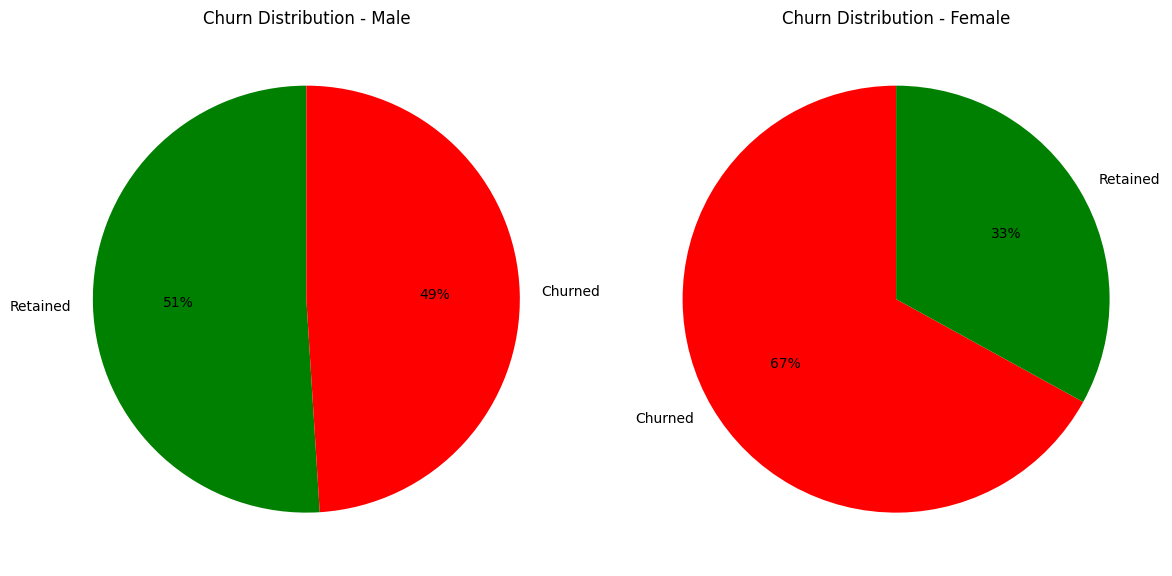

In [15]:

churn_pct = (df.groupby('Gender')['Churn Category']
               .value_counts(normalize=True) * 100)

churn_pct = churn_pct.round(0)

male_data = churn_pct['Male']
female_data = churn_pct['Female']

color_map = {
    'Churned': 'red',
    'Retained': 'green'
}

male_colors = [color_map[cat] for cat in male_data.index]
female_colors = [color_map[cat] for cat in female_data.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].pie(
    male_data.values,
    labels=male_data.index,
    colors=male_colors,
    autopct='%1.0f%%',
    startangle=90
)
axes[0].set_title('Churn Distribution - Male')

axes[1].pie(
    female_data.values,
    labels=female_data.index,
    colors=female_colors,
    autopct='%1.0f%%',
    startangle=90
)
axes[1].set_title('Churn Distribution - Female')

plt.tight_layout()
plt.show()


4. Does age have a significant impact on churn rate?

In [16]:
(df.groupby('Age_Group',observed=False)['Churn'].mean()*100).round(1).astype(str) + '%'

Age_Group
18-30     55.5%
30-42     45.3%
42-54     47.7%
54-66    100.0%
Name: Churn, dtype: object

5. Age group with the highest Churn Rate

In [17]:
(df.groupby('Age_Group',observed=False)['Churn'].mean()*100).sort_values(ascending=False).head(1).round(1).astype(str) + '%'

Age_Group
54-66    100.0%
Name: Churn, dtype: object

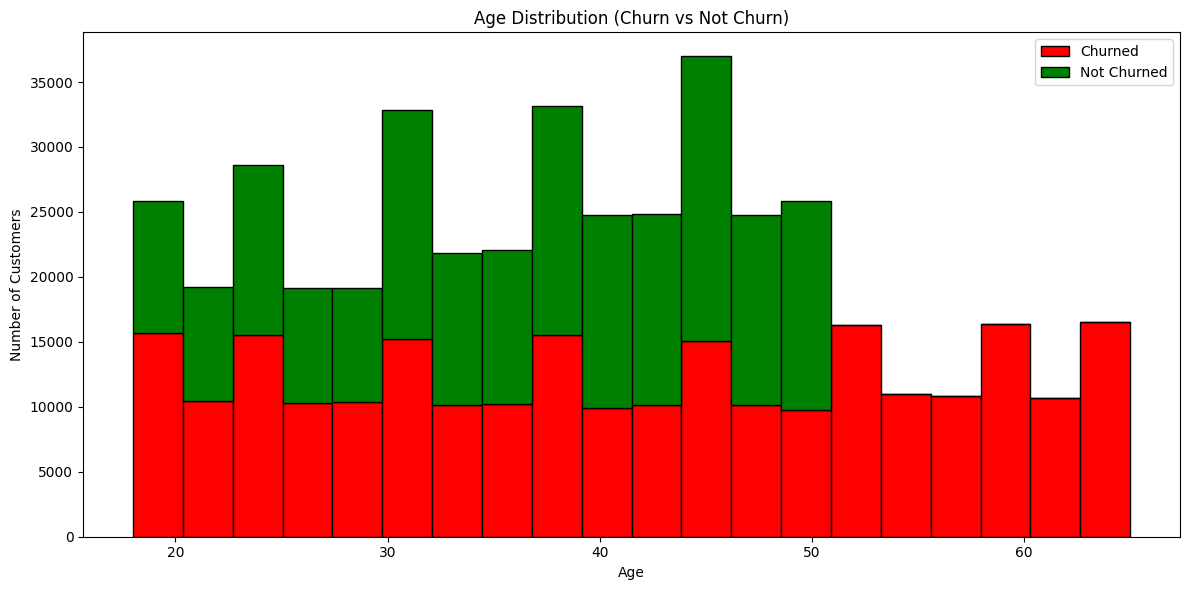

In [ ]:

age_min = df["Age"].min()
age_max = df["Age"].max()

bins = np.linspace(age_min, age_max, 21)  

# حساب التوزيعات
churn_counts, _ = np.histogram(df[df["Churn"] == 1]["Age"], bins=bins)
not_churn_counts, _ = np.histogram(df[df["Churn"] == 0]["Age"], bins=bins)

bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(12, 6))

# Churned تحت
plt.bar(
    bin_centers,
    churn_counts,
    width=(bins[1] - bins[0]),
    color='red',
    edgecolor="black",
    label="Churned"
)

# Not Churned فوق
plt.bar(
    bin_centers,
    not_churn_counts,
    width=(bins[1] - bins[0]),
    bottom=churn_counts,
    color='green',
    edgecolor="black",
    label="Not Churned"
)

plt.title("Age Distribution (Churn vs Not Churn)")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.show()



### 💛Usage Behavior

6. Does churn differ based on usage frequency?

In [19]:
(df.groupby('Usage Group',observed=False)['Churn'].mean()*100).round(1).astype(str)+'%'

Usage Group
1–10 per month     60.6%
10–20 per month    54.8%
20+ per month      55.0%
Name: Churn, dtype: object

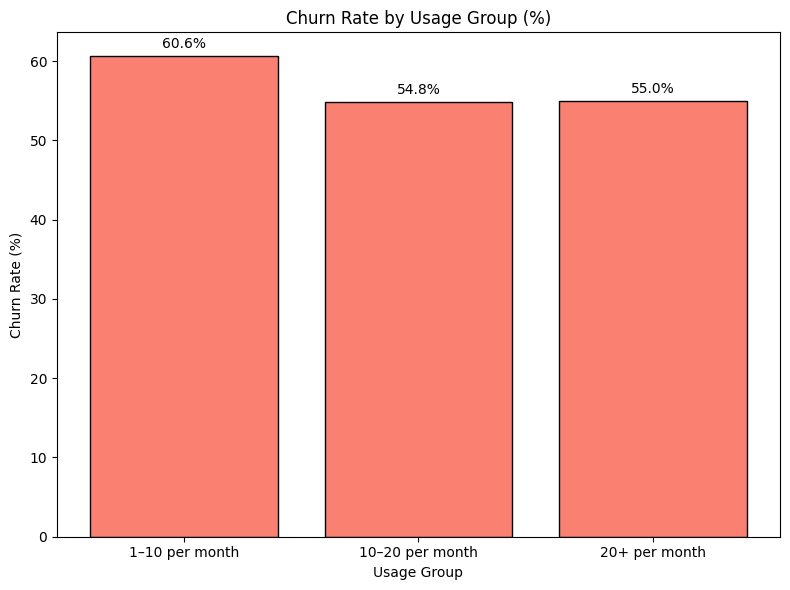

In [20]:

churn_pct = (df.groupby('Usage Group', observed=False)['Churn']
               .mean() * 100).round(1)

plt.figure(figsize=(8, 6))
plt.bar(churn_pct.index, churn_pct.values,
        color='salmon', edgecolor='black')

plt.title("Churn Rate by Usage Group (%)")
plt.xlabel("Usage Group")
plt.ylabel("Churn Rate (%)")

for i, v in enumerate(churn_pct.values):
    plt.text(i, v + 1, f"{v}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


7. Which usage frequency segments have the highest churn rates?

In [21]:
(df.groupby('Usage Group',observed=False)['Churn'].mean()*100).sort_values(ascending=False).head(1).round(1).astype(str)+'%'

Usage Group
1–10 per month    60.6%
Name: Churn, dtype: object

### 🤍Customer Tenure

8. Does churn vary based on customer tenure?

In [22]:
(df.groupby('Tenure_Group',observed=False)['Churn'].mean()*100).round(1).astype(str)+'%'

Tenure_Group
1-Year     58.5%
2-Years    63.2%
3-Years    54.9%
4-Years    54.0%
5-Years    54.4%
Name: Churn, dtype: object

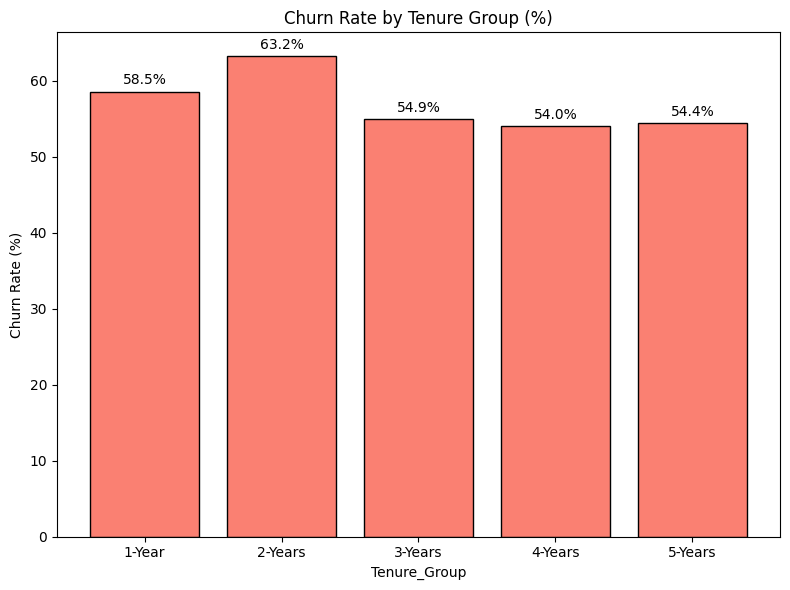

In [23]:

churn_pct = (df.groupby('Tenure_Group', observed=False)['Churn']
               .mean() * 100).round(1)

plt.figure(figsize=(8, 6))
plt.bar(churn_pct.index, churn_pct.values,
        color='salmon', edgecolor='black')

plt.title("Churn Rate by Tenure Group (%)")
plt.xlabel("Tenure_Group")
plt.ylabel("Churn Rate (%)")

for i, v in enumerate(churn_pct.values):
    plt.text(i, v + 1, f"{v}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

9. Are there specific tenure patterns that are strongly linked to churn?

In [24]:
(df.groupby('Tenure_Group',observed=False)['Churn'].mean()*100).sort_values(ascending=False).head(1).round(1).astype(str)+'%'

Tenure_Group
2-Years    63.2%
Name: Churn, dtype: object

### 💚Customer Support Interaction

10. What is the average number of supports calls for churned customers?

In [25]:
df[df['Churn']==1].groupby('Churn Category')['Support Calls'].mean()

Churn Category
Churned    5.144861
Name: Support Calls, dtype: float64

11. Is a higher number of support calls associated with increased churn rates?

In [26]:
(df.groupby('Support Calls')['Churn'].mean()*100).round(1).astype(str)+'%'    #yessss

Support Calls
0      30.3%
1      30.4%
2      31.6%
3      41.6%
4      58.5%
5      94.7%
6     100.0%
7     100.0%
8     100.0%
9     100.0%
10    100.0%
Name: Churn, dtype: object

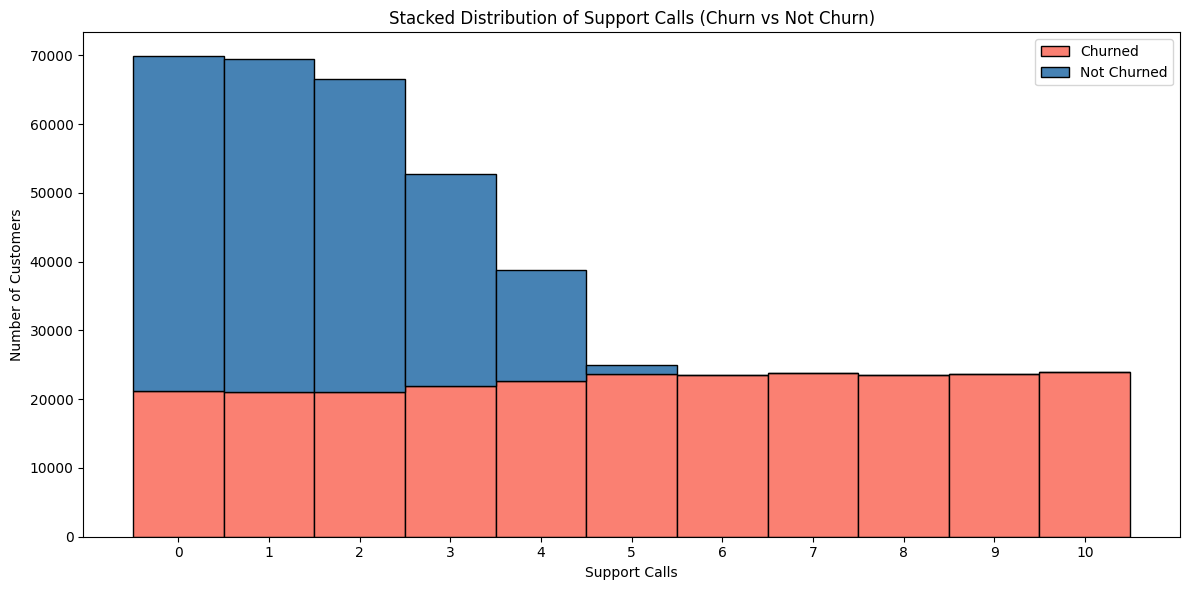

In [27]:

support_min = df["Support Calls"].min()   
support_max = df["Support Calls"].max() 

bins = np.arange(support_min, support_max + 2)

churn_counts, _ = np.histogram(
    df[df["Churn"] == 1]["Support Calls"],
    bins=bins
)

not_churn_counts, _ = np.histogram(
    df[df["Churn"] == 0]["Support Calls"],
    bins=bins
)

bin_centers = (bins[:-1] + bins[1:]) //2
bar_width = bins[1] - bins[0]

plt.figure(figsize=(12, 6))

plt.bar(
    bin_centers,
    churn_counts,
    width=bar_width,
    color='salmon',
    edgecolor='black',
    label='Churned'
)

plt.bar(
    bin_centers,
    not_churn_counts,
    width=bar_width,
    bottom=churn_counts,
    color='steelblue',
    edgecolor='black',
    label='Not Churned'
)

plt.title("Stacked Distribution of Support Calls (Churn vs Not Churn)")
plt.xlabel("Support Calls")
plt.ylabel("Number of Customers")
plt.xticks(bin_centers) 
plt.legend()
plt.tight_layout()
plt.show()


### 🧡Financial Behavior

12. Avg payment delay for churned vs non-churned

In [28]:
df.groupby('Churn Category')['Payment Delay'].mean()

Churn Category
Churned     15.217729
Retained    10.015500
Name: Payment Delay, dtype: float64

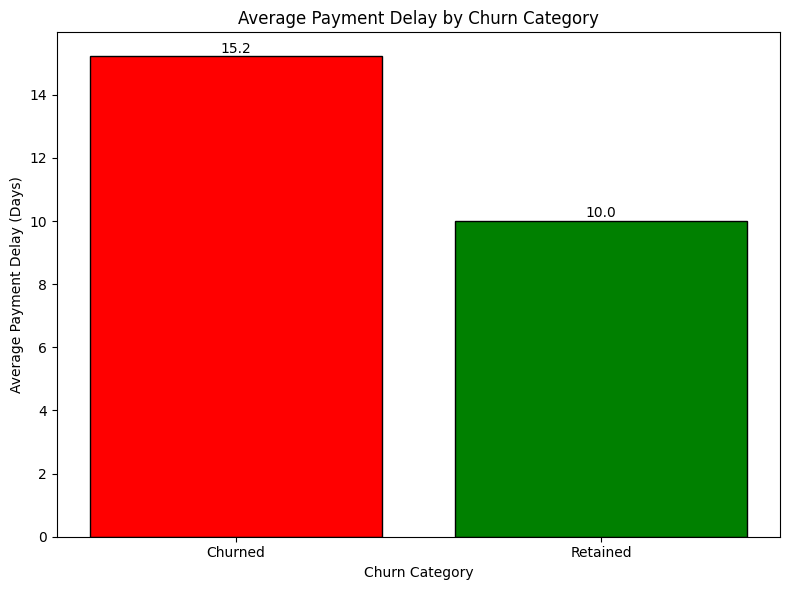

In [29]:
import matplotlib.pyplot as plt

delay_mean = df.groupby('Churn Category')['Payment Delay'].mean()

plt.figure(figsize=(8, 6))
plt.bar(
    delay_mean.index,
    delay_mean.values,
    color=['red' if cat == 'Churned' else 'green' for cat in delay_mean.index],
    edgecolor='black'
)

plt.title("Average Payment Delay by Churn Category")
plt.xlabel("Churn Category")
plt.ylabel("Average Payment Delay (Days)")

for i, v in enumerate(delay_mean.values):
    plt.text(i, v + 0.1, f"{v:.1f}", ha='center')

plt.tight_layout()
plt.show()


13. Does payment delay affect churn rates?

In [30]:
(df.groupby('Payment Delay Group',observed=False)['Churn'].mean()*100).round(1).astype(str)+'%' 

Payment Delay Group
1–10 days      46.5%
10–20 days     46.5%
20+days       100.0%
Name: Churn, dtype: object

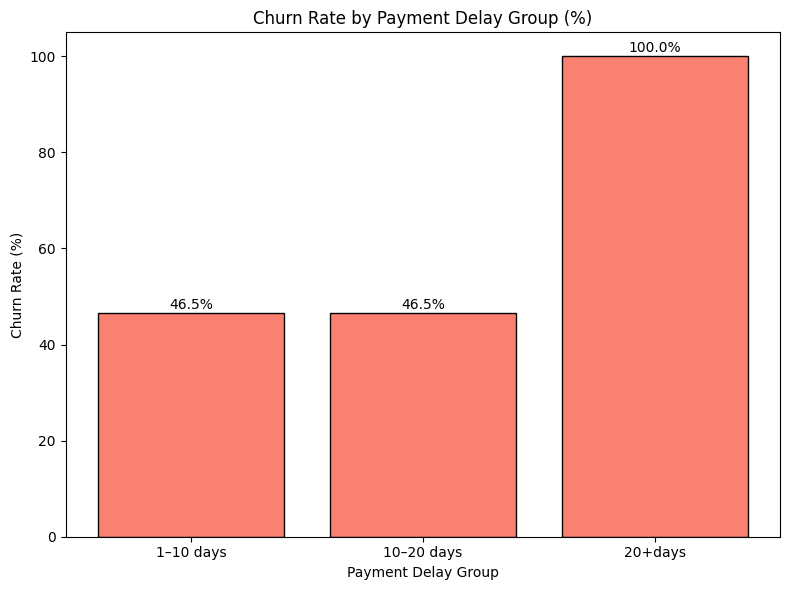

In [31]:

churn_pct = (df.groupby('Payment Delay Group', observed=False)['Churn']
               .mean() * 100).round(1)

plt.figure(figsize=(8, 6))
plt.bar(
    churn_pct.index,
    churn_pct.values,
    color='salmon',     
    edgecolor='black'
)

plt.title("Churn Rate by Payment Delay Group (%)")
plt.xlabel("Payment Delay Group")
plt.ylabel("Churn Rate (%)")

for i, v in enumerate(churn_pct.values):
    plt.text(i, v + 1, f"{v}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


14. Avg total spend for churned vs non-churned

In [32]:
round(df.groupby('Churn Category')['Total Spend'].mean(),2)

Churn Category
Churned     541.29
Retained    749.95
Name: Total Spend, dtype: float64

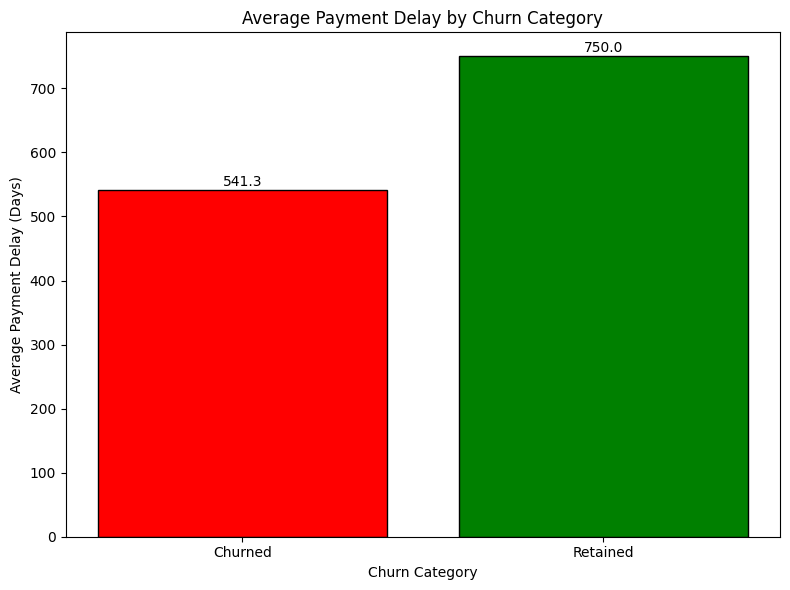

In [33]:
import matplotlib.pyplot as plt

spend_mean = round(df.groupby('Churn Category')['Total Spend'].mean(),2)

plt.figure(figsize=(8, 6))
plt.bar(
    spend_mean.index,
    spend_mean.values,
    color=['red' if cat == 'Churned' else 'green' for cat in spend_mean.index],
    edgecolor='black'
)

plt.title("Average Payment Delay by Churn Category")
plt.xlabel("Churn Category")
plt.ylabel("Average Payment Delay (Days)")

for i, v in enumerate(spend_mean.values):
    plt.text(i, v + 7, f"{v:.1f}", ha='center')

plt.tight_layout()
plt.show()


15. Do low-spending customers have higher churn rates?

In [34]:
df.groupby('Total Spend Group',observed=False)['Churn'].mean()     #yessss

Total Spend Group
100 - 200     1.000000
200 - 300     1.000000
300 - 400     1.000000
400 - 500     1.000000
500 - 600     0.414478
600 - 700     0.410641
700 - 800     0.415558
800 - 900     0.409571
900 - 1000    0.413224
Name: Churn, dtype: float64

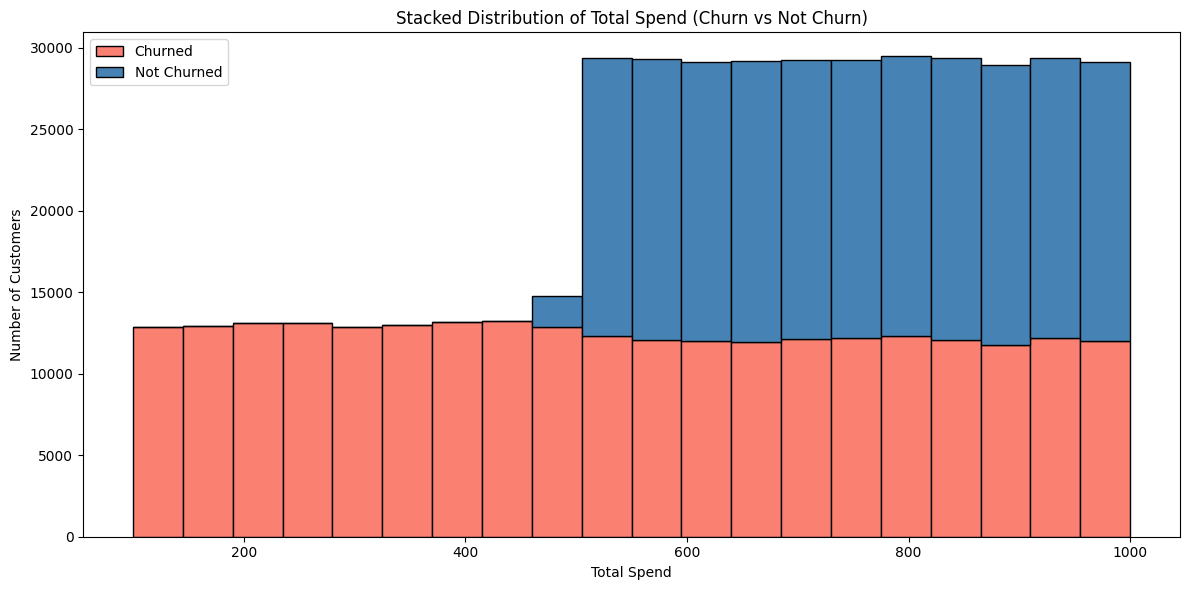

In [35]:
spend_min = df["Total Spend"].min()
spend_max = df["Total Spend"].max()
bins = np.linspace(spend_min, spend_max, 21)   

not_churn_counts, _ = np.histogram(
    df[df["Churn"] == 0]["Total Spend"],
    bins=bins
)

churn_counts, _ = np.histogram(
    df[df["Churn"] == 1]["Total Spend"],
    bins=bins
)


bin_centers = (bins[:-1] + bins[1:]) / 2
bar_width = bins[1] - bins[0]

plt.figure(figsize=(12, 6))

plt.bar(
    bin_centers,
    churn_counts,
    width=bar_width,
    color='salmon',
    edgecolor='black',
    label='Churned'
)

plt.bar(
    bin_centers,
    not_churn_counts,
    width=bar_width,
    bottom=churn_counts,
    color='steelblue',
    edgecolor='black',
    label='Not Churned'
)

plt.title("Stacked Distribution of Total Spend (Churn vs Not Churn)")
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.show()


### 💙Subscription & Contract Analysis

16. Which subscription type have the highest churn rate?

In [36]:
(df.groupby('Subscription Type')['Churn'].mean().head(1)*100).round(1).astype(str)+'%'

Subscription Type
Basic    58.2%
Name: Churn, dtype: object

17. How does Subscription Type affect churn?

In [37]:
(df.groupby('Subscription Type')['Churn'].mean()*100).round(1).astype(str)+'%'

Subscription Type
Basic       58.2%
Premium     55.9%
Standard    56.1%
Name: Churn, dtype: object

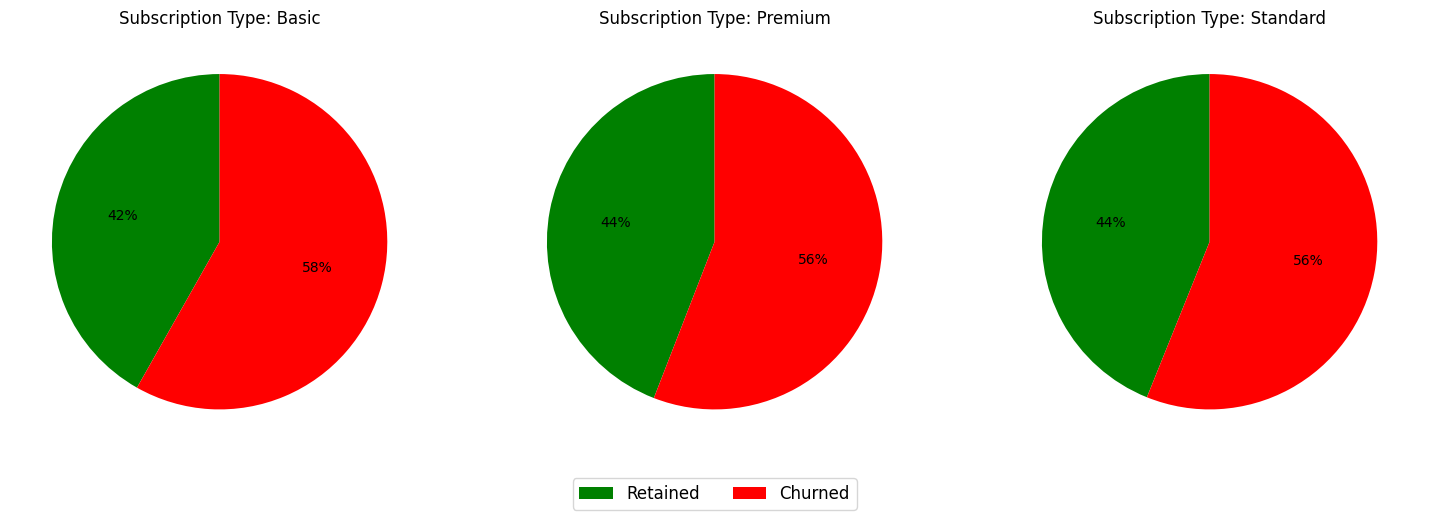

In [38]:

churn_pct = (df.groupby('Subscription Type')['Churn']
               .value_counts(normalize=True) * 100).round(1)

contract_lengths = churn_pct.index.get_level_values(0).unique()

fig, axes = plt.subplots(1, len(contract_lengths), figsize=(15, 5))

color_map = {0: 'green', 1: 'red'}
label_map = {0: 'Retained', 1: 'Churned'}

for ax, contract in zip(axes, contract_lengths):
    data = churn_pct[contract]

    values = []
    labels = []
    colors = []

    for churn_value in [0, 1]:
        if data.get(churn_value, 0) != 0:  
            values.append(data[churn_value])
            colors.append(color_map[churn_value])

    
    ax.pie(
        values,
        colors=colors,
        autopct='%1.0f%%',     
        startangle=90
    )

    ax.set_title(f"Subscription Type: {contract}")


fig.legend(
    ['Retained', 'Churned'],
    loc='lower center',
    ncol=2,
    fontsize=12
)

plt.tight_layout(rect=[0, 0.1, 1, 1])  
plt.show()

18. How does contract length affect churn?

In [39]:
(df.groupby('Contract Length')['Churn'].mean()*100).round(1).astype(str)+'%'

Contract Length
Annual        46.1%
Monthly      100.0%
Quarterly     46.0%
Name: Churn, dtype: object

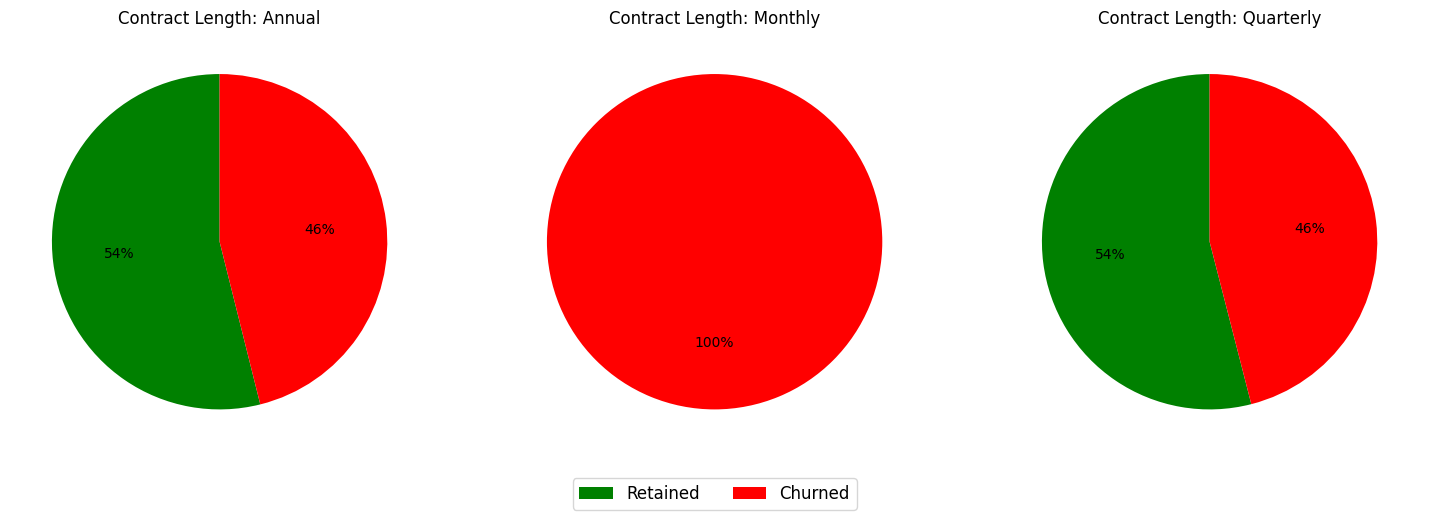

In [40]:

churn_pct = (df.groupby('Contract Length')['Churn']
               .value_counts(normalize=True) * 100).round(1)

contract_lengths = churn_pct.index.get_level_values(0).unique()

fig, axes = plt.subplots(1, len(contract_lengths), figsize=(15, 5))

color_map = {0: 'green', 1: 'red'}
label_map = {0: 'Retained', 1: 'Churned'}

for ax, contract in zip(axes, contract_lengths):
    data = churn_pct[contract]

    values = []
    labels = []
    colors = []

    for churn_value in [0, 1]:
        if data.get(churn_value, 0) != 0:  
            values.append(data[churn_value])
            colors.append(color_map[churn_value])

    
    ax.pie(
        values,
        colors=colors,
        autopct='%1.0f%%',     
        startangle=90
    )

    ax.set_title(f"Contract Length: {contract}")


fig.legend(
    ['Retained', 'Churned'],
    loc='lower center',
    ncol=2,
    fontsize=12
)

plt.tight_layout(rect=[0, 0.1, 1, 1])  
plt.show()


19. How does the customer churn rate vary based on the combination of Subscription Type and Contract Length?

In [41]:
(df.groupby(['Contract Length','Subscription Type'])['Churn'].mean()*100).round(1).astype(str)+'%'

Contract Length  Subscription Type
Annual           Basic                 47.5%
                 Premium               45.4%
                 Standard              45.4%
Monthly          Basic                100.0%
                 Premium              100.0%
                 Standard             100.0%
Quarterly        Basic                 47.6%
                 Premium               45.1%
                 Standard              45.5%
Name: Churn, dtype: object

<Figure size 1200x600 with 0 Axes>

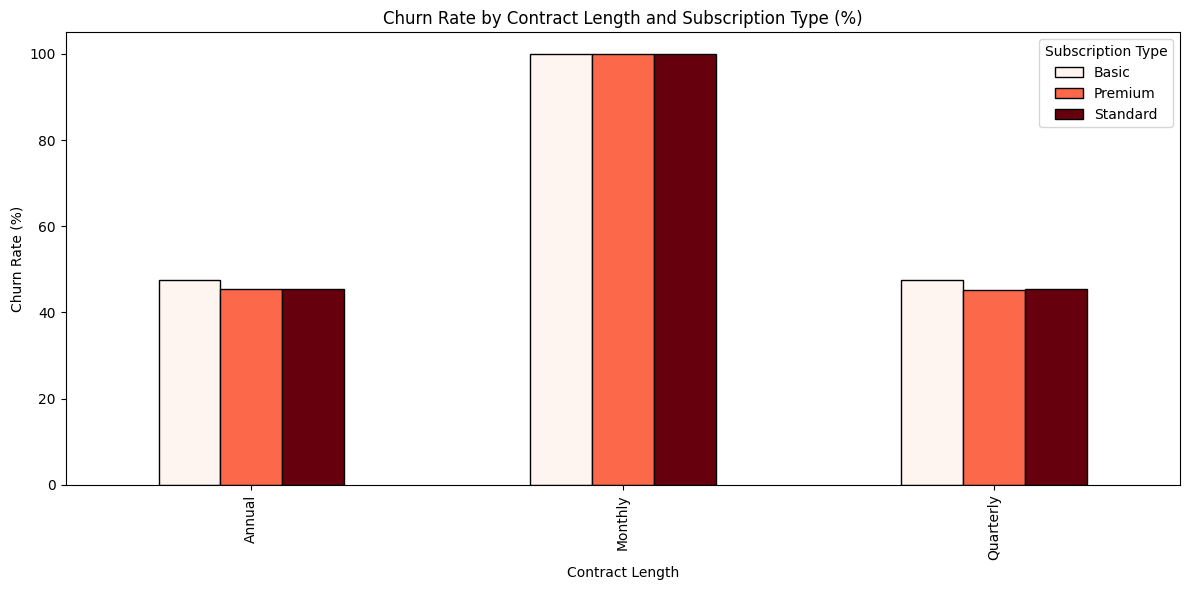

In [42]:

churn_pct = (df.groupby(['Contract Length','Subscription Type'])['Churn']
               .mean() * 100).round(1)

pivot_df = churn_pct.unstack()   

plt.figure(figsize=(12, 6))

pivot_df.plot(
    kind="bar",
    figsize=(12, 6),
    colormap="Reds",       
    edgecolor="black"
)

plt.title("Churn Rate by Contract Length and Subscription Type (%)")
plt.xlabel("Contract Length")
plt.ylabel("Churn Rate (%)")
plt.legend(title="Subscription Type")


plt.tight_layout()
plt.show()


### 💜Customer Engagement & Interaction

20. How does the number of days since the last interaction affect churn?

In [43]:
(df.groupby('Interaction_Level',observed=False)['Churn'].mean()*100).round(1).astype(str) + '%'

Interaction_Level
Very Active [Week]    49.2%
Active [2Weeks]       49.3%
At Risk [More]        65.1%
Name: Churn, dtype: object

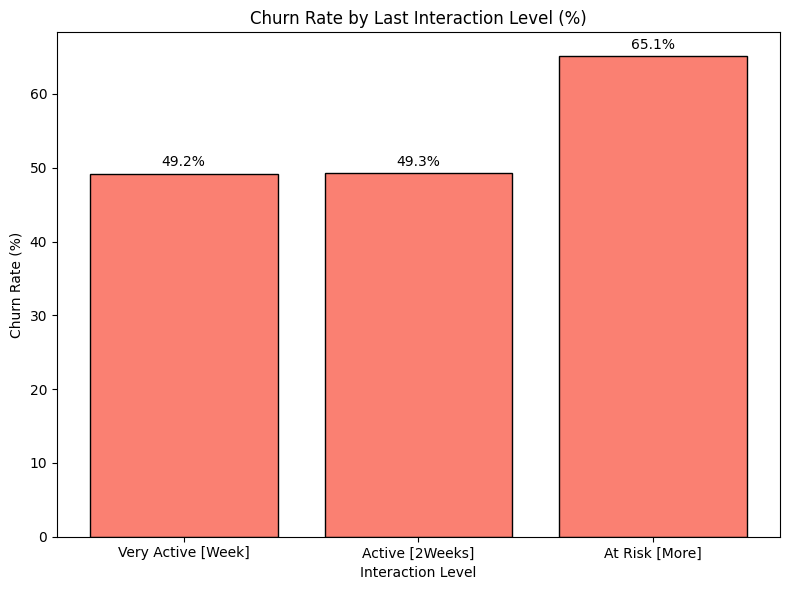

In [44]:
churn_pct = (df.groupby('Interaction_Level', observed=False)['Churn']
               .mean() * 100).round(1)

plt.figure(figsize=(8, 6))
plt.bar(
    churn_pct.index,
    churn_pct.values,
    color='salmon',     
    edgecolor='black'
)

plt.title("Churn Rate by Last Interaction Level (%)")
plt.xlabel("Interaction Level")
plt.ylabel("Churn Rate (%)")

for i, v in enumerate(churn_pct.values):
    plt.text(i, v + 1, f"{v}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

21. Is high support-call frequency combined with certain subscription types a key churn indicator?

In [45]:
df[df['Support Calls']>5].groupby(['Subscription Type','Support Calls'])['Churn'].mean()  #nooo

Subscription Type  Support Calls
Basic              6                1.0
                   7                1.0
                   8                1.0
                   9                1.0
                   10               1.0
Premium            6                1.0
                   7                1.0
                   8                1.0
                   9                1.0
                   10               1.0
Standard           6                1.0
                   7                1.0
                   8                1.0
                   9                1.0
                   10               1.0
Name: Churn, dtype: float64

22. Does usage frequency decline before churn (possible early warning sign)?

In [46]:
(df.groupby('Usage Group',observed=False)['Churn'].mean()*100).round(1).astype(str) + '%'    #Slightly

Usage Group
1–10 per month     60.6%
10–20 per month    54.8%
20+ per month      55.0%
Name: Churn, dtype: object

23. Is there any relationship between support calls and payment delay?

In [47]:
df.groupby('Payment Delay Group',observed=False)['Support Calls'].mean()  # maybe there is a problem in payment

Payment Delay Group
1–10 days     3.274168
10–20 days    3.278256
20+days       4.998501
Name: Support Calls, dtype: float64

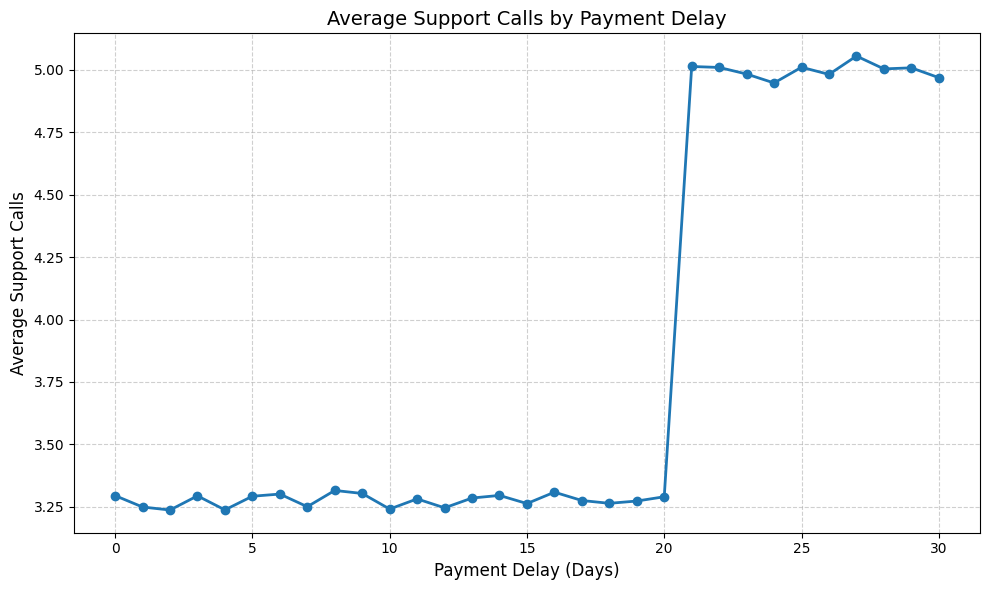

In [48]:
support_calls_by_delay = df.groupby('Payment Delay')['Support Calls'].mean()
plt.figure(figsize=(10,6))
plt.plot(support_calls_by_delay.index, support_calls_by_delay.values, marker='o', linestyle='-', linewidth=2)
plt.title('Average Support Calls by Payment Delay', fontsize=14)
plt.xlabel('Payment Delay (Days)', fontsize=12)
plt.ylabel('Average Support Calls', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

24. Age group with the highest total spend among churned customers

In [49]:
df[df['Churn']==1].groupby('Age_Group',observed=False)['Total Spend'].sum().sort_values(ascending=False).head(1)

Age_Group
54-66    35956897.58
Name: Total Spend, dtype: float64

25. Compare support call patterns for churned vs non-churned customers by age group

In [50]:
df.groupby(['Age_Group','Churn Category'],observed=False)['Support Calls'].mean()

Age_Group  Churn Category
18-30      Churned           5.172576
           Retained          0.936187
30-42      Churned           5.236812
           Retained          1.596006
42-54      Churned           5.166004
           Retained          2.056808
54-66      Churned           5.012770
           Retained               NaN
Name: Support Calls, dtype: float64

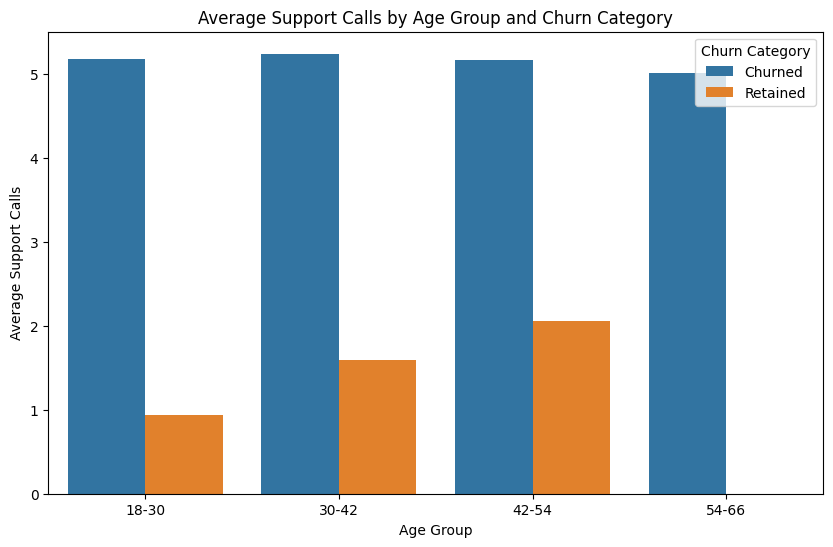

In [51]:

agg_df = df.groupby(['Age_Group','Churn Category'], observed=False)['Support Calls'].mean().reset_index()


plt.figure(figsize=(10,6))
sns.barplot(data=agg_df, x='Age_Group', y='Support Calls', hue='Churn Category')
plt.title('Average Support Calls by Age Group and Churn Category')
plt.ylabel('Average Support Calls')
plt.xlabel('Age Group')
plt.legend(title='Churn Category')
plt.show()


26. Relationship between age and usage frequency

In [52]:
df.groupby('Age_Group',observed=False)['Usage Frequency'].mean()

Age_Group
18-30    15.837127
30-42    15.843570
42-54    15.877322
54-66    15.544933
Name: Usage Frequency, dtype: float64

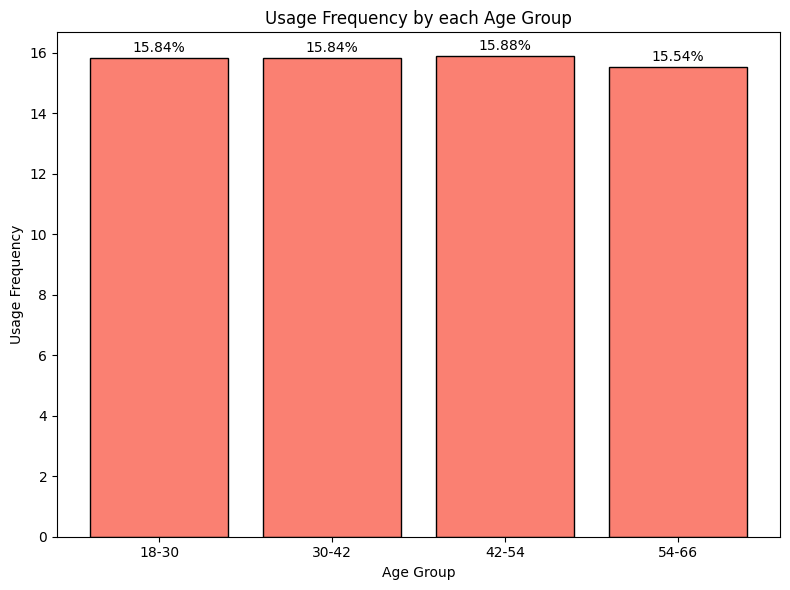

In [53]:
churn_pct = df.groupby('Age_Group',observed=False)['Usage Frequency'].mean().round(2)

plt.figure(figsize=(8, 6))
plt.bar(
    churn_pct.index,
    churn_pct.values,
    color='salmon',     
    edgecolor='black'
)

plt.title("Usage Frequency by each Age Group")
plt.xlabel("Age Group")
plt.ylabel("Usage Frequency")

for i, v in enumerate(churn_pct.values):
    plt.text(i, v+0.2 , f"{v}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

27. Relationship between age and payment delay

In [54]:
df.groupby('Age_Group',observed=False)['Payment Delay'].mean()

Age_Group
18-30    12.912636
30-42    12.422554
42-54    12.536741
54-66    15.020127
Name: Payment Delay, dtype: float64

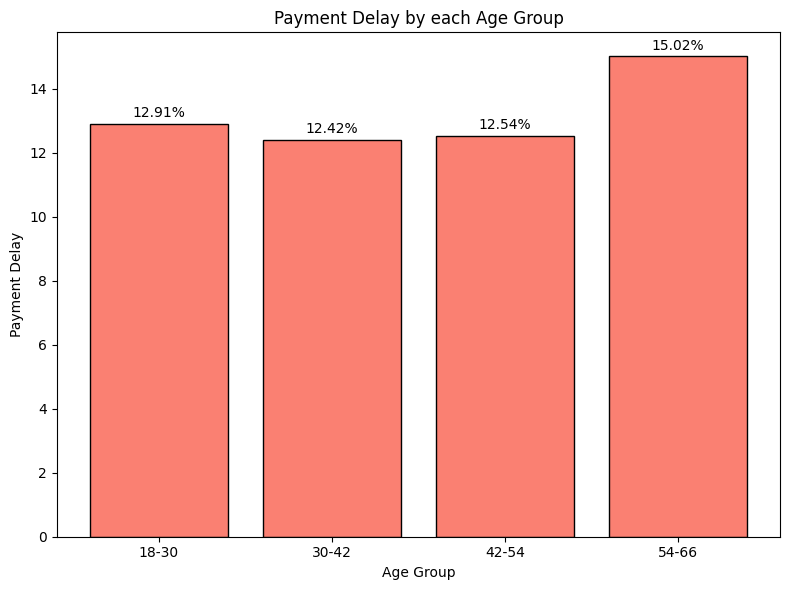

In [55]:
churn_pct = df.groupby('Age_Group',observed=False)['Payment Delay'].mean().round(2)

plt.figure(figsize=(8, 6))
plt.bar(
    churn_pct.index,
    churn_pct.values,
    color='salmon',     
    edgecolor='black'
)

plt.title("Payment Delay by each Age Group")
plt.xlabel("Age Group")
plt.ylabel("Payment Delay")

for i, v in enumerate(churn_pct.values):
    plt.text(i, v+0.2 , f"{v}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()